# 🛒 Customer Churn Prediction — E-Commerce

## Objectif
Prédire quels clients vont quitter une plateforme e-commerce et proposer des actions concrètes pour les retenir.

**Dataset** : 6 000 clients · 15 features · taux de churn 15.5%  
**Modèle final** : Random Forest · ROC-AUC 0.9934 · Recall 88.2%

---

In [1]:
# ── Imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, roc_curve)

# Affichage des graphiques directement dans le notebook
%matplotlib inline

print("✓ Librairies importées")

✓ Librairies importées


---
## 1. 📦 Data Collection & Preparation
Chargement des deux fichiers CSV, fusion sur `Customer_ID` et encodage des variables catégorielles.

In [2]:
# ── Chargement ────────────────────────────────────────────────
features = pd.read_csv('data/ecommerce_customer_features.csv')
targets  = pd.read_csv('data/ecommerce_customer_targets.csv')

# ── Fusion ────────────────────────────────────────────────────
df = features.merge(targets, on='Customer_ID')

# ── Encodage ──────────────────────────────────────────────────
df['loyalty_member'] = df['loyalty_member'].map({'Yes': 1, 'No': 0})
df['churned']        = df['churned'].map({'Yes': 1, 'No': 0})

# ── Résumé ────────────────────────────────────────────────────
print(f"✓ Dataset : {df.shape[0]:,} clients · {df.shape[1]-2} features")
print(f"✓ Churners : {df['churned'].sum():,} ({df['churned'].mean():.1%})")
print(f"✓ Valeurs manquantes : {df.isnull().sum().sum()}")
df.head()

✓ Dataset : 6,000 clients · 14 features
✓ Churners : 929 (15.5%)
✓ Valeurs manquantes : 0


,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,0,6.1,0.430,5.00,6.58,9.43,3.7,0
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,0,4.1,0.183,4.44,6.25,8.50,6.9,0
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,0,1.2,0.426,3.87,3.32,8.40,4.3,0
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,0,3.8,0.730,4.75,6.42,9.71,7.5,0
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,0,5.4,0.613,5.00,6.48,9.92,5.0,0


---
## 2. 📊 Exploratory Data Analysis (EDA)
Analyse visuelle pour identifier les patterns et les variables les plus discriminantes.

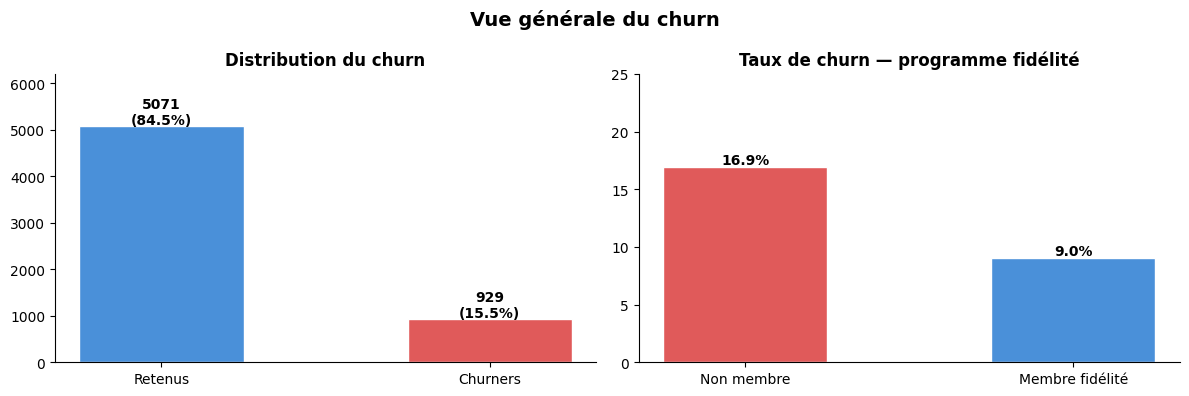

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Graphique 1 : Distribution target ────────────────────────
counts = df['churned'].value_counts()
axes[0].bar(['Retenus', 'Churners'], counts.values,
            color=['#4A90D9', '#E05A5A'], width=0.5, edgecolor='white')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribution du churn', fontweight='bold')
axes[0].set_ylim(0, 6200)
axes[0].spines[['top','right']].set_visible(False)

# ── Graphique 2 : Taux de churn par loyalty ───────────────────
churn_loyalty = df.groupby('loyalty_member')['churned'].mean() * 100
axes[1].bar(['Non membre', 'Membre fidélité'], churn_loyalty.values,
            color=['#E05A5A', '#4A90D9'], width=0.5, edgecolor='white')
for bar, val in zip(axes[1].patches, churn_loyalty.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Taux de churn — programme fidélité', fontweight='bold')
axes[1].set_ylim(0, 25)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Vue générale du churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insights clés
- Les churners n'ont pas acheté depuis **81 jours** en moyenne vs **20 jours** pour les retenus
- Le programme fidélité **divise le taux de churn par 2** (9% vs 17%)

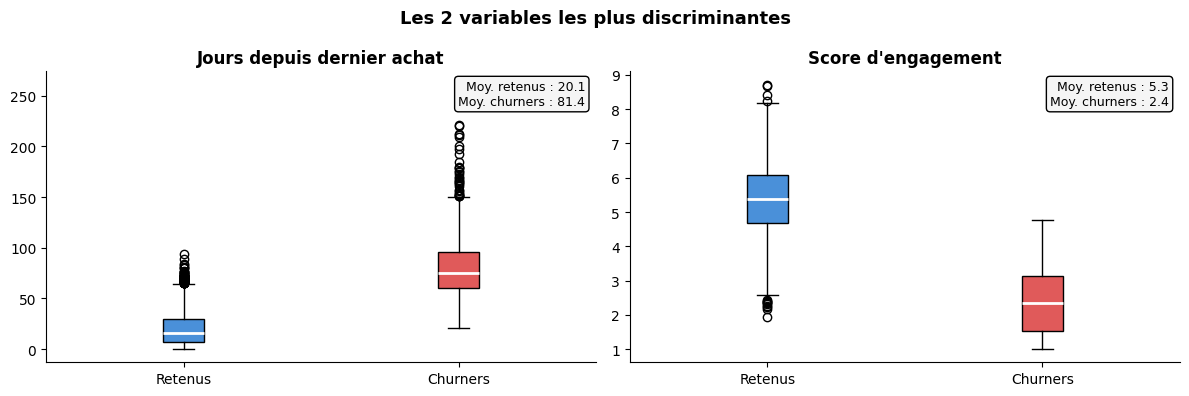

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
COLORS = ['#4A90D9', '#E05A5A']

for ax, col, label in zip(axes,
    ['days_since_last_purchase', 'engagement_score'],
    ['Jours depuis dernier achat', "Score d'engagement"]):
    
    data = [df[df['churned']==0][col], df[df['churned']==1][col]]
    bp = ax.boxplot(data, patch_artist=True,
                    tick_labels=['Retenus', 'Churners'],
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor(COLORS[0])
    bp['boxes'][1].set_facecolor(COLORS[1])
    
    m0 = df[df['churned']==0][col].mean()
    m1 = df[df['churned']==1][col].mean()
    ax.set_title(label, fontweight='bold')
    ax.annotate(f'Moy. retenus : {m0:.1f}\nMoy. churners : {m1:.1f}',
                xy=(0.98, 0.97), xycoords='axes fraction',
                ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5'))
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Les 2 variables les plus discriminantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. 🔧 Feature Engineering
Création de 6 nouvelles variables pour améliorer les performances du modèle.

In [5]:
bins = [0, 15, 30, 60, df['days_since_last_purchase'].max() + 1]
df['recency_segment'] = pd.cut(df['days_since_last_purchase'],
    bins=bins, labels=[0,1,2,3], include_lowest=True).astype(int)

df['orders_per_month'] = df['total_orders'] / (df['account_age_months'] + 1)

df['is_inactive']    = (df['days_since_last_purchase'] > 60).astype(int)

df['risk_score'] = (
    df['days_since_last_purchase'] / df['days_since_last_purchase'].max() * 0.4 +
    (1 - df['engagement_score']    / df['engagement_score'].max())         * 0.4 +
    (1 - df['satisfaction_score']  / df['satisfaction_score'].max())       * 0.2
)

df['low_engagement'] = (df['engagement_score'] < 3).astype(int)
df['high_support']   = (df['customer_support_tickets'] >= 2).astype(int)

# Résumé des corrélations
new_feats = ['is_inactive','low_engagement','risk_score',
             'recency_segment','orders_per_month','high_support']
corr = df[new_feats].corrwith(df['churned']).sort_values(ascending=False)
print("Corrélation des nouvelles features avec le churn :")
print(corr.round(3).to_string())
print(f"\n✓ Dataset enrichi : {df.shape[1]-2} features au total")

Corrélation des nouvelles features avec le churn :
low_engagement      0.780
is_inactive         0.776
risk_score          0.772
recency_segment     0.659
high_support        0.081
orders_per_month   -0.053

✓ Dataset enrichi : 20 features au total


---
## 4. 🤖 Machine Learning
Entraînement de 3 modèles sur 80% des données, évaluation sur 20%.

In [6]:
feature_cols = [c for c in df.columns if c not in ['Customer_ID', 'churned']]
X = df[feature_cols]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), X_train_sc, X_test_sc),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=100, random_state=42), X_train, X_test),
}

results = {}
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    proba  = model.predict_proba(X_te)[:, 1]
    pred   = model.predict(X_te)
    report = classification_report(y_test, pred, output_dict=True)
    results[name] = {
        'model': model, 'proba': proba, 'pred': pred,
        'auc':       roc_auc_score(y_test, proba),
        'precision': report['1']['precision'],
        'recall':    report['1']['recall'],
        'f1':        report['1']['f1-score'],
        'accuracy':  report['accuracy'],
    }
    print(f"{name:25} | AUC: {results[name]['auc']:.4f} | Recall: {results[name]['recall']:.4f}")

print("\n✓ 3 modèles entraînés")

Logistic Regression       | AUC: 0.9939 | Recall: 0.8710
Random Forest             | AUC: 0.9934 | Recall: 0.8817
Gradient Boosting         | AUC: 0.9912 | Recall: 0.8763

✓ 3 modèles entraînés


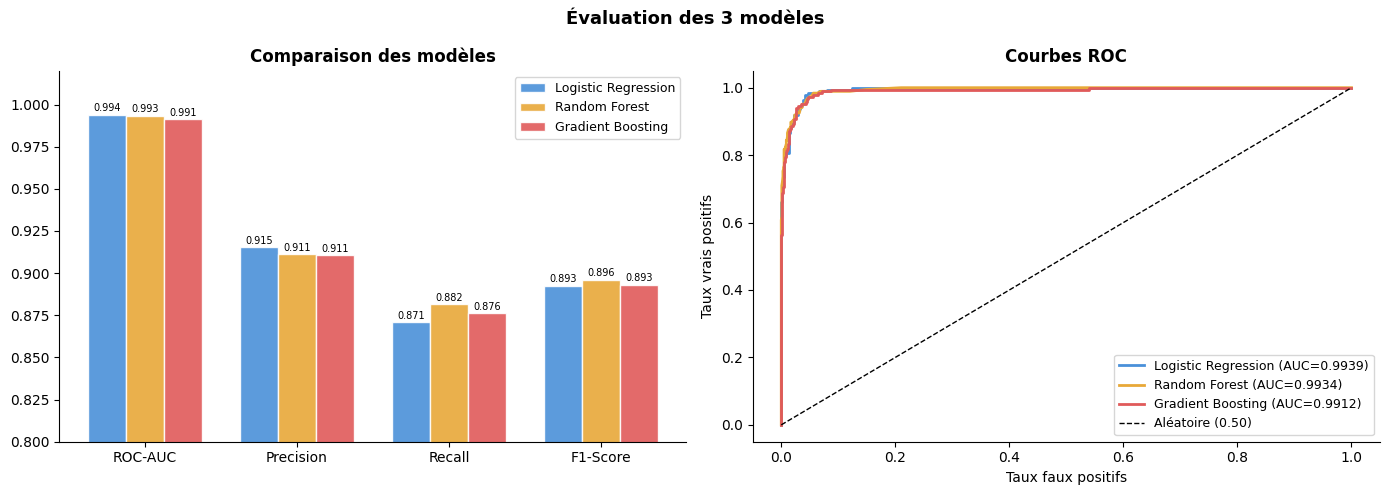

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4A90D9', '#E8A838', '#E05A5A']
model_names = list(results.keys())

# ── Graphique 1 : Comparaison métriques ───────────────────────
metrics = ['auc', 'precision', 'recall', 'f1']
labels  = ['ROC-AUC', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results[name][m] for m in metrics]
    bars = axes[0].bar(x + i*width, vals, width, label=name,
                       color=color, edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002,
                     f'{v:.3f}', ha='center', fontsize=7)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0.80, 1.02)
axes[0].set_title('Comparaison des modèles', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# ── Graphique 2 : Courbes ROC ─────────────────────────────────
for name, color in zip(model_names, colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['proba'])
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name} (AUC={results[name]['auc']:.4f})")

axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='Aléatoire (0.50)')
axes[1].set_xlabel('Taux faux positifs')
axes[1].set_ylabel('Taux vrais positifs')
axes[1].set_title('Courbes ROC', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Évaluation des 3 modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. 📏 Évaluation détaillée — Random Forest
Analyse approfondie du meilleur modèle : matrice de confusion et distribution des probabilités.

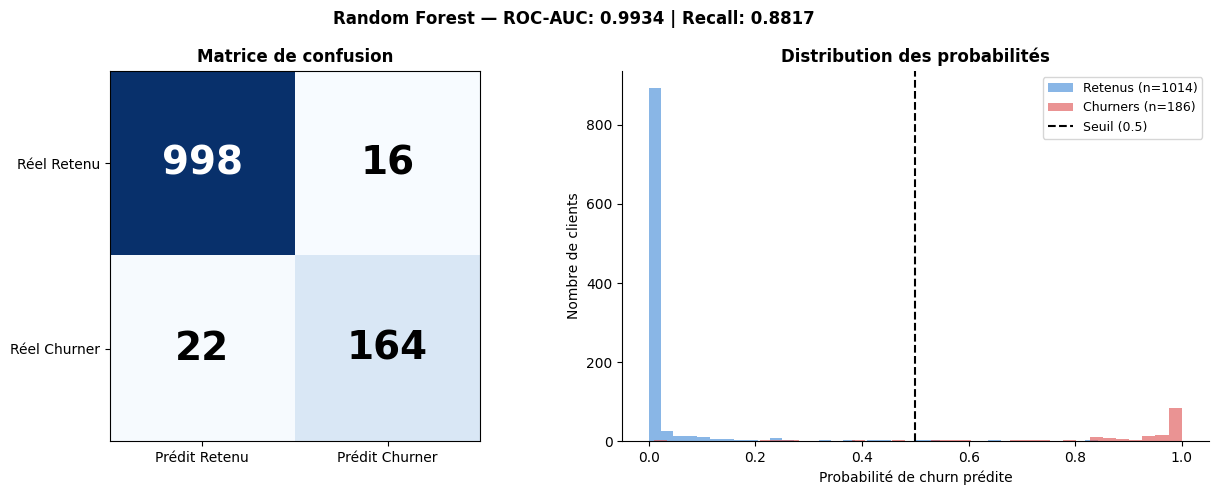


✓ Churners détectés    : 164  (vrais positifs)
✗ Churners ratés       : 22  (faux négatifs)
⚠ Fausses alertes      : 16  (faux positifs)
✓ Retenus bien classés : 998  (vrais négatifs)


In [8]:
rf    = results['Random Forest']['model']
proba = results['Random Forest']['proba']
pred  = results['Random Forest']['pred']
cm    = confusion_matrix(y_test, pred)
TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Matrice de confusion ──────────────────────────────────────
im = axes[0].imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=28, fontweight='bold', color=color)
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Prédit Retenu', 'Prédit Churner'])
axes[0].set_yticklabels(['Réel Retenu', 'Réel Churner'])
axes[0].set_title('Matrice de confusion', fontweight='bold')

# ── Distribution des probabilités ────────────────────────────
axes[1].hist(proba[y_test==0], bins=40, alpha=0.65,
             color='#4A90D9', label=f'Retenus (n={sum(y_test==0)})')
axes[1].hist(proba[y_test==1], bins=40, alpha=0.65,
             color='#E05A5A', label=f'Churners (n={sum(y_test==1)})')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5,
                label='Seuil (0.5)')
axes[1].set_xlabel('Probabilité de churn prédite')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Distribution des probabilités', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f'Random Forest — ROC-AUC: {results["Random Forest"]["auc"]:.4f} | Recall: {results["Random Forest"]["recall"]:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Churners détectés    : {TP}  (vrais positifs)")
print(f"✗ Churners ratés       : {FN}  (faux négatifs)")
print(f"⚠ Fausses alertes      : {FP}  (faux positifs)")
print(f"✓ Retenus bien classés : {TN}  (vrais négatifs)")

---
## 6. 💡 Business Insights & Plan d'actions
Segmentation des clients par niveau de risque et recommandations concrètes.

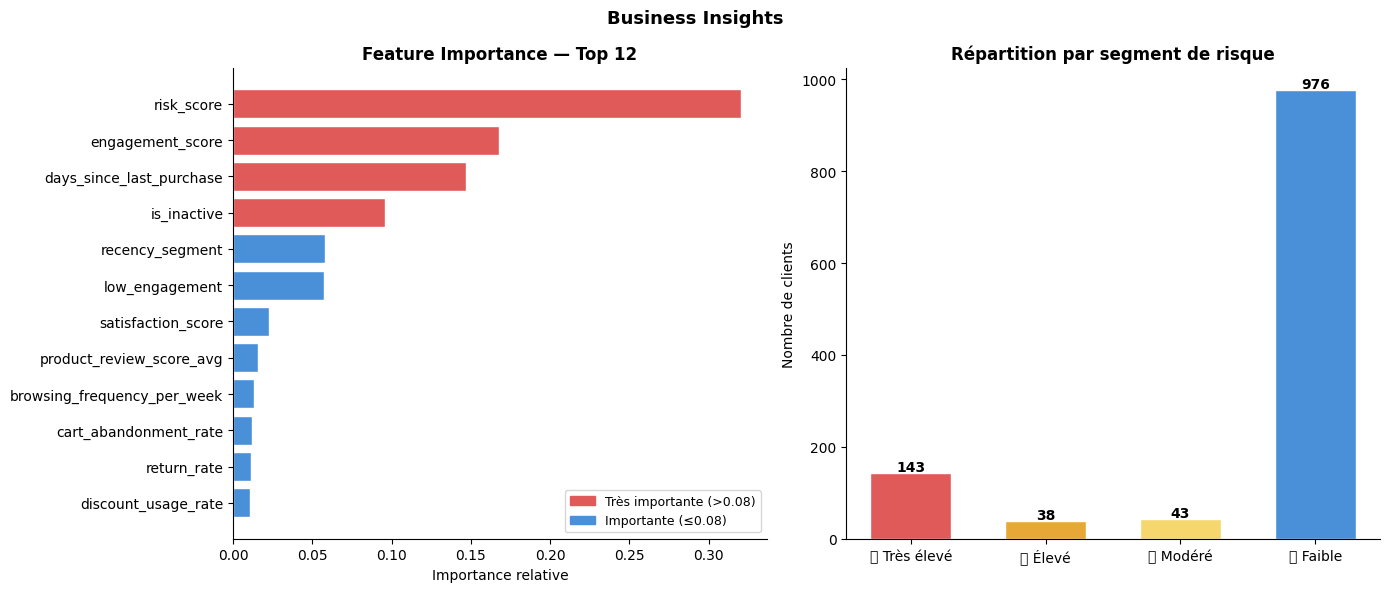

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Feature Importance ────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True).tail(12)
colors_imp  = ['#E05A5A' if v > 0.08 else '#4A90D9' for v in importances.values]
axes[0].barh(importances.index, importances.values,
             color=colors_imp, edgecolor='white')
axes[0].set_title('Feature Importance — Top 12', fontweight='bold')
axes[0].set_xlabel('Importance relative')
axes[0].spines[['top','right']].set_visible(False)
p1 = mpatches.Patch(color='#E05A5A', label='Très importante (>0.08)')
p2 = mpatches.Patch(color='#4A90D9', label='Importante (≤0.08)')
axes[0].legend(handles=[p1,p2], fontsize=9)

# ── Segmentation par risque ───────────────────────────────────
test_df = X_test.copy()
test_df['churn_proba'] = proba
test_df['churned']     = y_test.values

def risk_level(p):
    if p >= 0.8:   return 'Très élevé 🔴'
    elif p >= 0.5: return 'Élevé 🟠'
    elif p >= 0.2: return 'Modéré 🟡'
    else:          return 'Faible 🟢'

test_df['risk_level'] = test_df['churn_proba'].apply(risk_level)

segments   = ['Très élevé 🔴','Élevé 🟠','Modéré 🟡','Faible 🟢']
seg_colors = ['#E05A5A','#E8A838','#F5D76E','#4A90D9']
counts_seg = [len(test_df[test_df['risk_level']==s]) for s in segments]

bars = axes[1].bar(range(4), counts_seg, color=seg_colors,
                   edgecolor='white', width=0.6)
for bar, val in zip(bars, counts_seg):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(['🔴 Très élevé','🟠 Élevé','🟡 Modéré','🟢 Faible'])
axes[1].set_title('Répartition par segment de risque', fontweight='bold')
axes[1].set_ylabel('Nombre de clients')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Business Insights', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 🎯 Plan d'actions par segment

| Segment | Clients | Profil | Actions recommandées |
|---|---|---|---|
| 🔴 Très élevé (≥80%) | 143 | Inactif 86j, engagement 2.0 | Email personnalisé + réduction 20-30% |
| 🟠 Élevé (50-80%) | 38 | Inactif 56j, engagement 3.4 | Offre flash + recommandations produits |
| 🟡 Modéré (20-50%) | 43 | Inactif 52j, engagement 3.6 | Newsletter + points fidélité bonus |
| 🟢 Faible (<20%) | 976 | Actif 19j, engagement 5.4 | Programme fidélité + upsell |

### 💰 Impact financier estimé
- Valeur annuelle moyenne par client : **~963 USD**
- Clients à risque élevé détectés : **181**
- Revenu potentiellement préservé (rétention 50%) : **~87 000 USD**

---
## ✅ Conclusion

| Métrique | Score |
|---|---|
| ROC-AUC | **0.9934** |
| Recall | **88.2%** |
| Precision | **91.1%** |
| Accuracy | **96.8%** |

**Les 3 facteurs principaux de churn :**
1. `low_engagement` — score d'engagement < 3 → 92% de churn
2. `is_inactive` — aucun achat depuis >60j → 88% de churn  
3. `risk_score` — score composite inactivité + engagement + satisfaction

> Ce projet démontre qu'une approche Data Science end-to-end permet non seulement de prédire le churn avec une haute précision, mais aussi de traduire ces prédictions en actions business concrètes et chiffrées.